# LSTM Image Classification on CIFAR-10
## Cách 2: Mỗi cột của ảnh là một bước thời gian

**Ý tưởng:** Ảnh CIFAR-10 có kích thước 32×32×3. Ta coi mỗi **cột** (column) của ảnh là một bước thời gian (time step).
- Sequence length = 32 (số cột)
- Input size = 32 × 3 = 96 (mỗi cột gồm 32 pixel × 3 kênh màu RGB)

**So sánh với Row-wise:** Cách này quét ảnh từ trái sang phải thay vì từ trên xuống dưới.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Chuẩn bị dữ liệu CIFAR-10

In [2]:
# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = 10
BIDIRECTIONAL = True

# Cách biểu diễn: Column-wise
SEQUENCE_LENGTH = 32  # Số cột của ảnh
INPUT_SIZE = 32 * 3  # Mỗi cột: 32 pixel × 3 kênh = 96

print(f"Sequence Length: {SEQUENCE_LENGTH}")
print(f"Input Size: {INPUT_SIZE}")

Sequence Length: 32
Input Size: 96


In [3]:
# Transform
transform_train = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)

# Download CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

# Tên các lớp
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:02<00:00, 79.0MB/s] 


Training samples: 50000
Test samples: 10000


## 2. Minh họa cách biểu diễn Column-wise

Original image shape: torch.Size([3, 32, 32])
Column-wise sequence shape: torch.Size([32, 96])
  → Sequence length (time steps): 32
  → Input size (features/step): 96


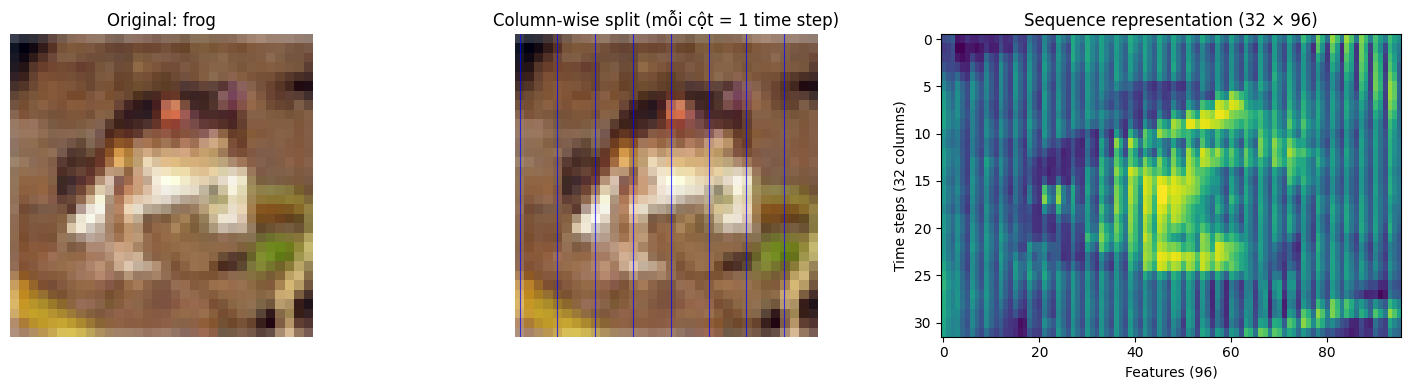

In [4]:
# Lấy 1 ảnh mẫu
sample_img, sample_label = train_dataset[0]
print(f"Original image shape: {sample_img.shape}")  # (3, 32, 32)

# Chuyển đổi: (C, H, W) -> (W, H*C) = (32, 96)
# Mỗi CỘT là 1 time step, mỗi time step có 96 features
img_col = sample_img.permute(2, 1, 0)  # (W, H, C) = (32, 32, 3)
img_col = img_col.reshape(32, -1)  # (32, 96)
print(f"Column-wise sequence shape: {img_col.shape}")  # (32, 96)
print(f"  → Sequence length (time steps): {img_col.shape[0]}")
print(f"  → Input size (features/step): {img_col.shape[1]}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ảnh gốc
img_display = sample_img.permute(1, 2, 0).numpy()
img_display = (img_display - img_display.min()) / (
    img_display.max() - img_display.min()
)
axes[0].imshow(img_display)
axes[0].set_title(f"Original: {classes[sample_label]}")
axes[0].axis("off")

# Hiển thị cách chia cột
axes[1].imshow(img_display)
for i in range(0, 32, 4):
    axes[1].axvline(x=i, color="blue", linewidth=0.8, alpha=0.7)
axes[1].set_title("Column-wise split (mỗi cột = 1 time step)")
axes[1].set_xlabel("Time steps →")
axes[1].axis("off")

# Sequence heatmap
axes[2].imshow(img_col.numpy(), aspect="auto", cmap="viridis")
axes[2].set_title("Sequence representation (32 × 96)")
axes[2].set_xlabel("Features (96)")
axes[2].set_ylabel("Time steps (32 columns)")

plt.tight_layout()
plt.show()

## 3. Định nghĩa mô hình LSTM

In [5]:
class LSTM_ColumnClassifier(nn.Module):
    """LSTM classifier treating each column as a time step."""

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        num_classes,
        bidirectional=True,
        dropout=0.3,
    ):
        super(LSTM_ColumnClassifier, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Layer normalization cho input
        self.input_norm = nn.LayerNorm(input_size)

        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0,
        )

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1),
        )

        # Classifier head
        lstm_output_size = hidden_size * self.num_directions
        self.classifier = nn.Sequential(
            nn.LayerNorm(lstm_output_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x):
        # x shape: (batch, channels=3, H=32, W=32)
        batch_size = x.size(0)

        # Reshape: (batch, C, H, W) -> (batch, W, H*C)
        # Mỗi CỘT là 1 time step
        x = x.permute(0, 3, 2, 1)  # (batch, W, H, C)
        x = x.reshape(batch_size, 32, -1)  # (batch, 32, 96)

        # Layer norm
        x = self.input_norm(x)

        # LSTM
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden_size * num_directions)

        # Attention
        attn_weights = self.attention(lstm_out)  # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)  # (batch, seq_len, 1)
        context = torch.sum(
            attn_weights * lstm_out, dim=1
        )  # (batch, hidden_size * num_directions)

        # Classification
        out = self.classifier(context)
        return out


# Tạo model
model = LSTM_ColumnClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    bidirectional=BIDIRECTIONAL,
).to(device)

# In thông tin model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()
print(model)

Total parameters: 694,603
Trainable parameters: 694,603

LSTM_ColumnClassifier(
  (input_norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (lstm): LSTM(96, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 4. Huấn luyện mô hình

In [6]:
# Loss và Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

# Early Stopping
early_stop_patience = 7  # Dừng nếu sau 7 epoch liên tiếp test acc không cải thiện
early_stop_counter = 0

# Training loop
train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ---- Evaluation ----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss = running_loss / len(test_loader)
    test_acc = 100.0 * correct / total
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    # Scheduler step
    scheduler.step(test_acc)

    elapsed = time.time() - start_time

    # Save best model + Early Stopping
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_lstm_column.pth")
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
        f"Best: {best_acc:.2f}% | Time: {elapsed:.1f}s"
    )

    # Early stopping check
    if early_stop_counter >= early_stop_patience:
        print(
            f"\nEarly stopping at epoch {epoch + 1}! No improvement for {early_stop_patience} epochs."
        )
        break

print(f"\nBest Test Accuracy: {best_acc:.2f}%")

Epoch [1/50] Train Loss: 1.7382 | Train Acc: 38.01% | Test Loss: 1.5360 | Test Acc: 45.03% | Best: 45.03% | Time: 11.5s
Epoch [2/50] Train Loss: 1.5204 | Train Acc: 46.11% | Test Loss: 1.4286 | Test Acc: 48.68% | Best: 48.68% | Time: 10.7s
Epoch [3/50] Train Loss: 1.4179 | Train Acc: 50.06% | Test Loss: 1.3898 | Test Acc: 50.00% | Best: 50.00% | Time: 10.4s
Epoch [4/50] Train Loss: 1.3412 | Train Acc: 52.49% | Test Loss: 1.3362 | Test Acc: 52.34% | Best: 52.34% | Time: 10.6s
Epoch [5/50] Train Loss: 1.2760 | Train Acc: 54.54% | Test Loss: 1.2994 | Test Acc: 53.64% | Best: 53.64% | Time: 10.5s
Epoch [6/50] Train Loss: 1.2250 | Train Acc: 56.63% | Test Loss: 1.2800 | Test Acc: 54.56% | Best: 54.56% | Time: 10.4s
Epoch [7/50] Train Loss: 1.1746 | Train Acc: 58.51% | Test Loss: 1.2830 | Test Acc: 54.89% | Best: 54.89% | Time: 10.6s
Epoch [8/50] Train Loss: 1.1343 | Train Acc: 59.82% | Test Loss: 1.2652 | Test Acc: 55.45% | Best: 55.45% | Time: 10.4s
Epoch [9/50] Train Loss: 1.0928 | Train 

## 5. Visualize kết quả training

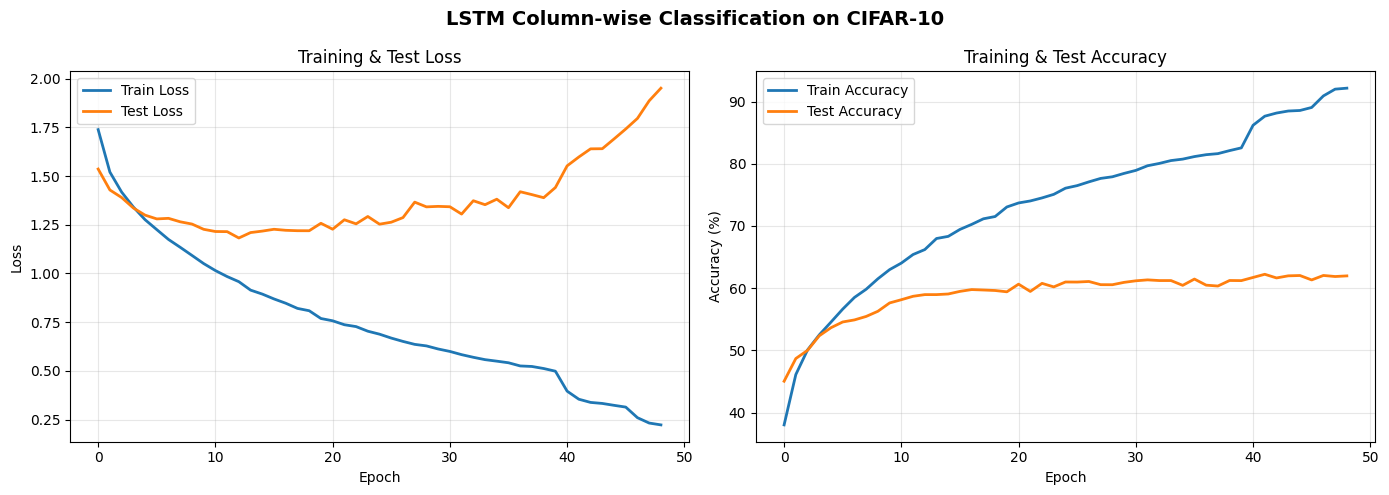

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label="Train Loss", linewidth=2)
axes[0].plot(test_losses, label="Test Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Test Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label="Train Accuracy", linewidth=2)
axes[1].plot(test_accs, label="Test Accuracy", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training & Test Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "LSTM Column-wise Classification on CIFAR-10", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 6. Đánh giá chi tiết trên tập test

In [8]:
# Load best model
model.load_state_dict(torch.load("best_lstm_column.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print("=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=classes))

=== Classification Report ===
              precision    recall  f1-score   support

    airplane       0.68      0.67      0.67      1000
  automobile       0.71      0.73      0.72      1000
        bird       0.55      0.50      0.52      1000
         cat       0.43      0.47      0.45      1000
        deer       0.56      0.52      0.54      1000
         dog       0.53      0.55      0.54      1000
        frog       0.68      0.70      0.69      1000
       horse       0.72      0.66      0.69      1000
        ship       0.72      0.74      0.73      1000
       truck       0.66      0.70      0.68      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000



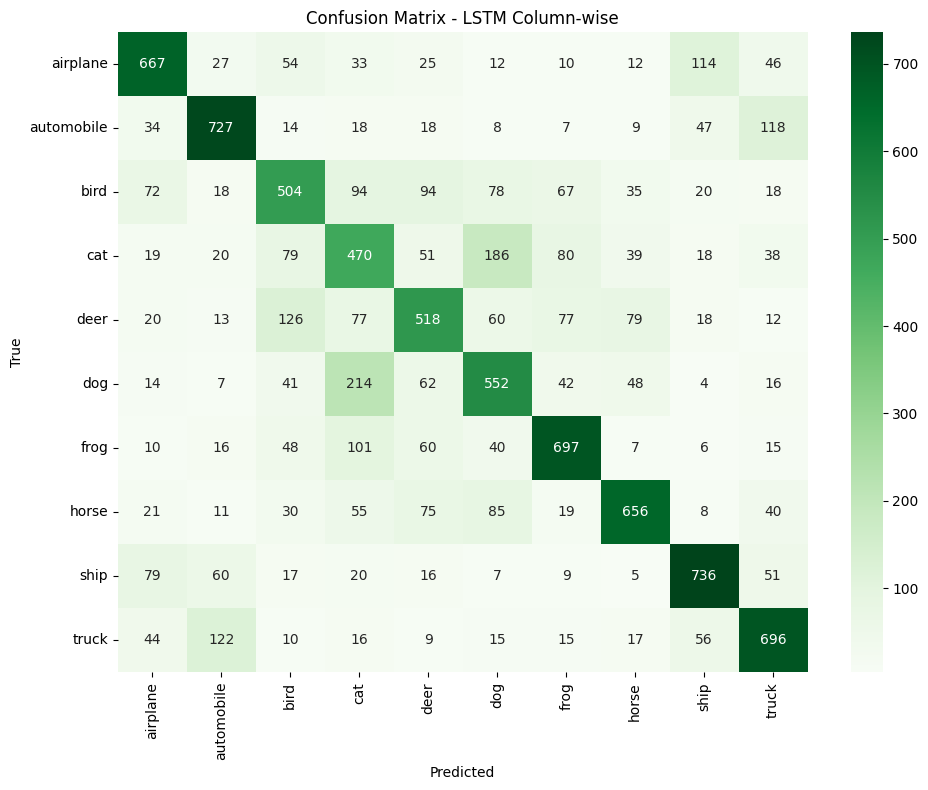

In [9]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - LSTM Column-wise")
plt.tight_layout()
plt.show()

In [10]:
# Accuracy per class
class_correct = {}
class_total = {}
for i in range(NUM_CLASSES):
    mask = all_labels == i
    class_correct[classes[i]] = (all_preds[mask] == i).sum()
    class_total[classes[i]] = mask.sum()

print("\n=== Per-class Accuracy ===")
for cls_name in classes:
    acc = 100.0 * class_correct[cls_name] / class_total[cls_name]
    print(
        f"{cls_name:>12s}: {acc:.2f}% ({class_correct[cls_name]}/{class_total[cls_name]})"
    )


=== Per-class Accuracy ===
    airplane: 66.70% (667/1000)
  automobile: 72.70% (727/1000)
        bird: 50.40% (504/1000)
         cat: 47.00% (470/1000)
        deer: 51.80% (518/1000)
         dog: 55.20% (552/1000)
        frog: 69.70% (697/1000)
       horse: 65.60% (656/1000)
        ship: 73.60% (736/1000)
       truck: 69.60% (696/1000)


## 7. Visualize attention weights

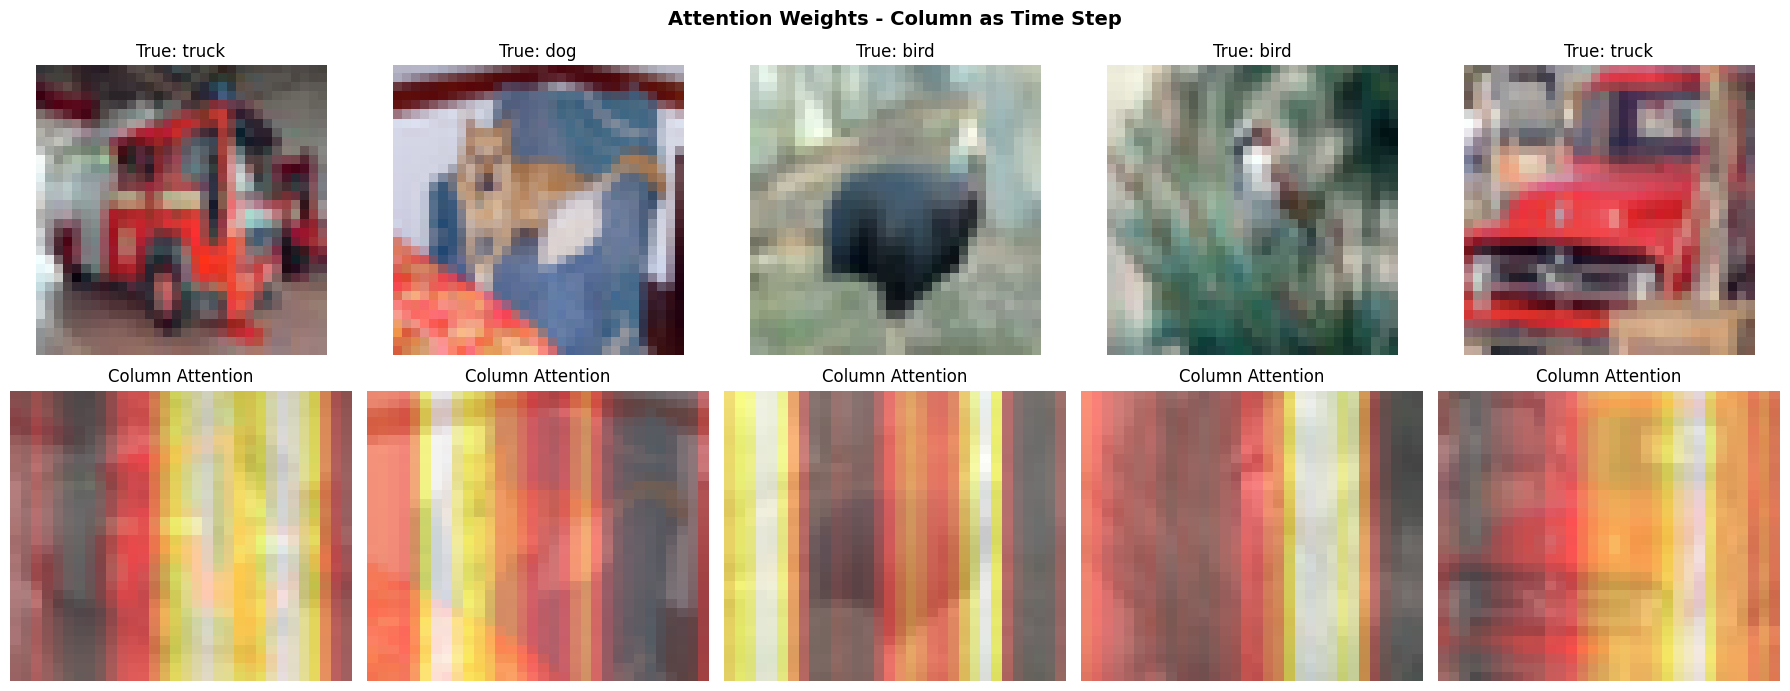

In [11]:
def get_attention_weights(model, image):
    """Trích xuất attention weights để xem LSTM chú ý vào cột nào."""
    model.eval()
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)  # (1, 3, 32, 32)
        batch_size = x.size(0)

        # Reshape column-wise
        x = x.permute(0, 3, 2, 1).reshape(batch_size, 32, -1)
        x = model.input_norm(x)

        # LSTM
        lstm_out, _ = model.lstm(x)

        # Attention
        attn_weights = model.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)

        return attn_weights.squeeze().cpu().numpy()


# Visualize attention cho một vài ảnh mẫu
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i in range(5):
    idx = np.random.randint(len(test_dataset))
    img, label = test_dataset[idx]
    attn = get_attention_weights(model, img)

    # Ảnh gốc
    img_show = img.permute(1, 2, 0).numpy()
    img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
    axes[0, i].imshow(img_show)
    axes[0, i].set_title(f"True: {classes[label]}")
    axes[0, i].axis("off")

    # Attention heatmap (column-wise → repeat theo chiều ngang)
    attn_2d = np.repeat(attn[np.newaxis, :], 32, axis=0)  # (32, 32)
    axes[1, i].imshow(img_show, alpha=0.5)
    axes[1, i].imshow(attn_2d, cmap="hot", alpha=0.5, aspect="auto")
    axes[1, i].set_title("Column Attention")
    axes[1, i].axis("off")

plt.suptitle("Attention Weights - Column as Time Step", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Tổng kết

**Cách biểu diễn Column-wise:**
- **Ưu điểm:** LSTM quét ảnh từ trái sang phải, có thể nắm bắt thông tin spatial theo chiều ngang tốt hơn.
- **Nhược điểm:** Tương tự row-wise, mất thông tin spatial giữa các cột. Mỗi time step chỉ nhìn thấy 1 cột pixel.
- **Sequence Length:** 32 (giống row-wise)
- **Input Size:** 96 (giống row-wise)

**So sánh với Row-wise:**
- Hai cách biểu diễn có cùng dimensions nhưng quét theo hướng khác nhau.
- Hiệu quả phụ thuộc vào đặc trưng dữ liệu: nếu đối tượng có cấu trúc ngang mạnh → column-wise có thể tốt hơn.